### Gaussian Feature Map Embedding

In [137]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matchms

In [138]:
filename = "gnps_positive_ionmode_unique_inchikey_cleaned_by_matchms_and_lookups.json"
reference_spectrums_lookup = matchms.importing.load_from_json(f"src/data/{filename}")

In [139]:
from matchms.filtering import normalize_intensities
from matchms.filtering import require_minimum_number_of_peaks
from matchms.filtering import select_by_mz
from matchms.filtering import select_by_relative_intensity

def post_process(s):
    s = normalize_intensities(s)
    s = select_by_mz(s, mz_from=0, mz_to=1000)
    s = require_minimum_number_of_peaks(s, n_required=10)
    s = select_by_relative_intensity(s, intensity_from=0.01, intensity_to=1.0)
    return s

In [140]:
# apply filters to the data
spectrums = [post_process(s) for s in reference_spectrums_lookup]

# omit spectrums that didn't qualify for analysis
spectrums = [s for s in spectrums if s is not None]

In [141]:
from matchms.filtering.add_fingerprint import add_fingerprint

spectrums = [add_fingerprint(s, fingerprint_type="daylight", nbits=2048) for s in spectrums]

In [142]:
from matchms.similarity import FingerprintSimilarity

similarity_measure = FingerprintSimilarity(similarity_measure="jaccard")
scores_mol_similarity = similarity_measure.matrix(spectrums, spectrums)

In [143]:
n = len(spectrums)

n_pairs = 20_000

i = np.random.randint(0, n, size=n_pairs)
j = np.random.randint(0, n, size=n_pairs)

# remove self-pairs
mask = i < j
i = i[mask]
j = j[mask]

pairs = list(zip(i, j))

In [144]:
spectra_pairs = [ (spectrums[i].peaks.mz, spectrums[i].peaks.intensities, 
                   spectrums[j].peaks.mz, spectrums[j].peaks.intensities) for i, j in pairs ]
pairs = np.array(pairs)
labels = scores_mol_similarity[pairs[:, 0], pairs[:, 1]]
labels

array([0.38235294, 0.50982143, 0.23170732, ..., 0.13140604, 0.20658135,
       0.52535885])

Jaccard similarity distribution

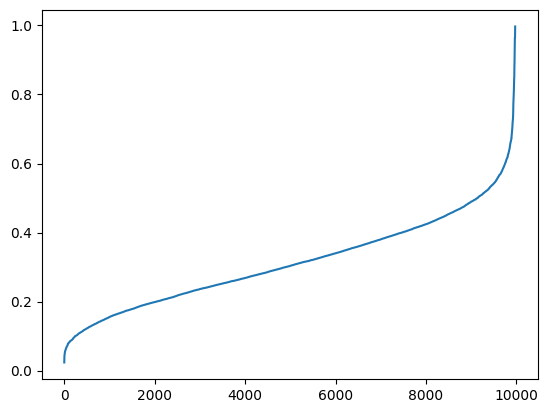

In [145]:
plt.plot(sorted(labels))

Each peak is mapped to a gaussian function in $D$ dimensions. Then, every spectra is represented by a weighted sum of gaussians.

The input of the model is then a concatenation of the interaction features and the spectra features.

A dataset can be built from the pairs of spectra and their 'labels'.

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

class GaussianSpectrumEmbedder:
    def __init__(self, n_anchors: int = 100, mz_min: float = 50.0,
                 mz_max: float = 1000.0, sigma: float = None):
        self.anchors = np.linspace(mz_min, mz_max, n_anchors)  
        self.sigma = sigma or (self.anchors[1] - self.anchors[0]) / 2.0

    def phi(self, mz: float) -> np.ndarray:
        """φ(mz) → R^D  via Gaussian bumps centered at each anchor."""
        return np.exp(-0.5 * ((mz - self.anchors) / self.sigma) ** 2)

    def embed(self, mz: np.ndarray, intensity: np.ndarray) -> np.ndarray:
        """
        v = Σ_k  int_k · φ(mz_k)
        Intensity-weighted sum of Gaussian features → fixed R^D vector.
        Equivalent to an RBF kernel evaluated between this spectrum and
        a set of 'anchor spectra' (Dirac peaks at each anchor position).
        """
        intensity = intensity / (intensity.sum() + 1e-8)         
        v = np.zeros(len(self.anchors))
        for mz_k, int_k in zip(mz, intensity):
            v += int_k * self.phi(mz_k)
        return v                                                   

    # vectorised version (faster for large spectra)
    def embed_fast(self, mz: np.ndarray, intensity: np.ndarray) -> np.ndarray:
        intensity = intensity / (intensity.sum() + 1e-8)
        phi_matrix = np.exp(-0.5 * ((mz[:, None] - self.anchors[None, :]) / self.sigma) ** 2)
        return (intensity[:, None] * phi_matrix).sum(axis=0)      


def interaction_features(v_i: np.ndarray, v_j: np.ndarray) -> np.ndarray:
    """
    Symmetric feature vector from two spectrum embeddings.
    Order of (i, j) does not matter → suitable for unordered pairs.
    """
    prod  = v_i * v_j                           
    diff  = np.abs(v_i - v_j)                   
    ssum  = v_i + v_j                           
    cos   = np.dot(v_i, v_j) / (             
                np.linalg.norm(v_i) * np.linalg.norm(v_j) + 1e-8)  

    return np.concatenate([prod, diff, ssum, [cos]])  


def build_dataset(pairs, labels, embedder: GaussianSpectrumEmbedder):
    X, y = [], []
    for (mz_i, int_i, mz_j, int_j), label in zip(pairs, labels):  
        v_i = embedder.embed_fast(np.array(mz_i), np.array(int_i))
        v_j = embedder.embed_fast(np.array(mz_j), np.array(int_j))
        X.append(interaction_features(v_i, v_j))
        y.append(label)
    return np.array(X), np.array(y)

Training step

In [165]:
embedder = GaussianSpectrumEmbedder(n_anchors=200, mz_min=50, mz_max=1000, sigma=10)

X, y = build_dataset(spectra_pairs, labels, embedder=embedder)      

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = MLPRegressor(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
)
model.fit(X_scaled, y)


def predict(mz_i, int_i, mz_j, int_j):
    v_i  = embedder.embed_fast(np.array(mz_i), np.array(int_i))
    v_j  = embedder.embed_fast(np.array(mz_j), np.array(int_j))
    feat = interaction_features(v_i, v_j).reshape(1, -1)
    return model.predict(scaler.transform(feat))[0]

In [166]:
predict(spectrums[0].peaks.mz, spectrums[0].peaks.intensities, spectrums[1].peaks.mz, spectrums[1].peaks.intensities)

np.float64(0.38047019360463047)

In [167]:
predicted = [predict(spectrums[i].peaks.mz, spectrums[i].peaks.intensities, spectrums[j].peaks.mz, spectrums[j].peaks.intensities)
             for i, j in pairs]
predicted = np.array(predicted)

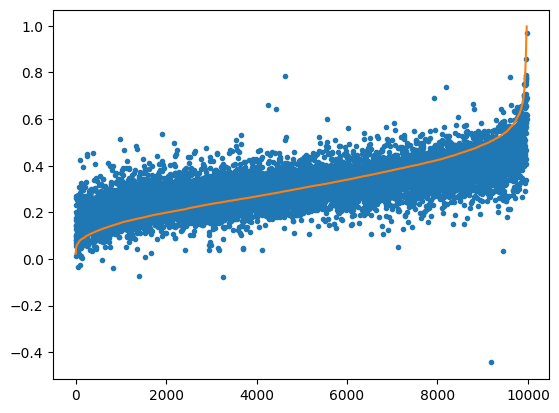

In [168]:
idx = np.argsort(labels)

plt.plot(predicted[idx], '.')
plt.plot(labels[idx])

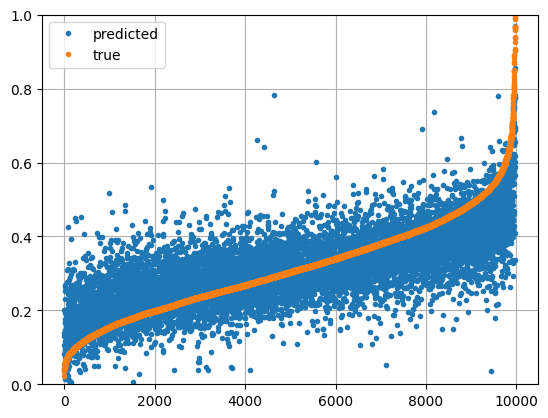

In [169]:
plt.plot(predicted[idx], '.', label='predicted')
plt.plot(labels[idx], '.', label='true')
plt.legend()
plt.ylim(0, 1)
plt.grid()
plt.show()

Test step

In [170]:
n = len(spectrums)

n_pairs = 20_000

i = np.random.randint(0, n, size=n_pairs)
j = np.random.randint(0, n, size=n_pairs)

# remove self-pairs
mask = i < j
i = i[mask]
j = j[mask]

test_pairs = list(zip(i, j))

In [171]:
test_spectra_pairs = [ (spectrums[i].peaks.mz, spectrums[i].peaks.intensities, 
                   spectrums[j].peaks.mz, spectrums[j].peaks.intensities) for i, j in test_pairs ]
test_pairs = np.array(test_pairs)
test_labels = scores_mol_similarity[test_pairs[:, 0], test_pairs[:, 1]]
test_labels

array([0.32320872, 0.12721239, 0.59564541, ..., 0.20906568, 0.42196532,
       0.50623269])

In [172]:
predicted_test = [predict(spectrums[i].peaks.mz, spectrums[i].peaks.intensities, spectrums[j].peaks.mz, spectrums[j].peaks.intensities)
             for i, j in test_pairs]
predicted_test = np.array(predicted_test)

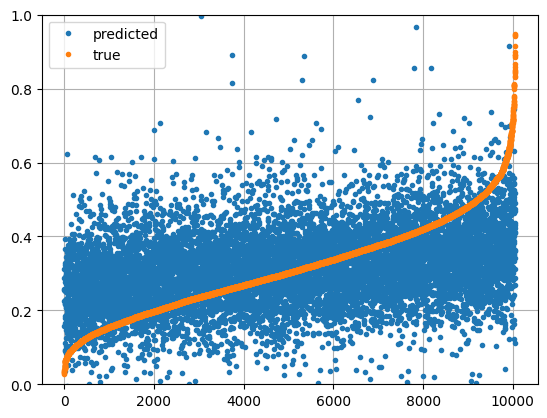

In [173]:
idx = np.argsort(test_labels)
plt.plot(predicted_test[idx], '.', label='predicted')
plt.plot(test_labels[idx], '.', label='true')
plt.legend()
plt.ylim(0, 1)
plt.grid()
plt.show()